<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/medmnist_SAGAN_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install medmnist -q


In [17]:
# 1. Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from medmnist import INFO, ChestMNIST
import numpy as np
import matplotlib.pyplot as plt

# Parameters
IMG_SIZE = 28
N_CHANNELS = 1
N_CLASSES = 2
LABEL_EMB_DIM = 8
LATENT_DIM = 32
NOISE_DIM = 32
BATCH_SIZE = 64
EPOCHS_AE = 10  # Set higher for real experiments
EPOCHS_GAN = 50
LAMBDA_GP = 7
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Loading
info = INFO['chestmnist']
DataClass = ChestMNIST
train_dataset = DataClass(split='train', download=True, transform=transforms.ToTensor())
test_dataset = DataClass(split='test', download=True, transform=transforms.ToTensor())
train_loader = DataLoader([(img, int(label[0])) for img, label in train_dataset], batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader([(img, int(label[0])) for img, label in test_dataset], batch_size=16, shuffle=True)




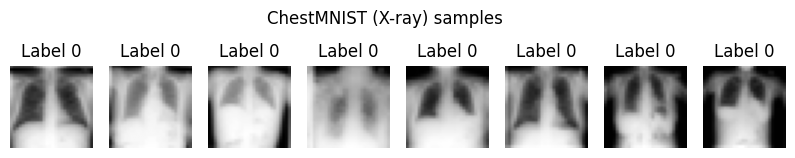

In [18]:
imgs, labels = next(iter(test_loader))
plt.figure(figsize=(10,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(imgs[i,0], cmap='gray')
    plt.title(f"Label {labels[i]}")
    plt.axis('off')
plt.suptitle("ChestMNIST (X-ray) samples")
plt.show()


In [12]:
import os
from torchvision.utils import save_image

def save_generated_images(fake_imgs, labels, out_dir='generated_xray'):
    os.makedirs(out_dir, exist_ok=True)
    # fake_imgs = (fake_imgs * 255).clamp(0, 255).to(torch.uint8)  # Remove this line
    for i in range(fake_imgs.size(0)):
        label = int(labels[i].item())
        class_dir = os.path.join(out_dir, str(label))
        os.makedirs(class_dir, exist_ok=True)
        save_image(fake_imgs[i], os.path.join(class_dir, f"sample_{i}.png"))
    print(f"Saved {fake_imgs.size(0)} images to {out_dir}/")

In [6]:
# 3. Models
class ConditionalEncoder(nn.Module):
    def __init__(self, latent_dim, n_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(N_CHANNELS + label_emb_dim, 32, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    def forward(self, x, labels):
        label_emb = self.label_emb(labels)
        label_map = label_emb.unsqueeze(2).unsqueeze(3).expand(-1, -1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([x, label_map], dim=1)
        x = self.conv(x)
        x = self.flatten(x)
        z = self.fc(x)
        return z

class ConditionalDecoder(nn.Module):
    def __init__(self, latent_dim, n_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + label_emb_dim, 64), nn.ReLU(),
            nn.Linear(64, 64 * (IMG_SIZE // 4) * (IMG_SIZE // 4)), nn.ReLU()
        )
        self.unflatten = nn.Unflatten(1, (64, IMG_SIZE // 4, IMG_SIZE // 4))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, N_CHANNELS, 4, 2, 1), nn.Sigmoid()
        )
    def forward(self, z, labels):
        label_emb = self.label_emb(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        x = self.fc(z_cond)
        x = self.unflatten(x)
        x = self.deconv(x)
        return x

class LatentGenerator(nn.Module):
    def __init__(self, noise_dim, latent_dim, n_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.fc = nn.Sequential(
            nn.Linear(noise_dim + label_emb_dim, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    def forward(self, noise, labels):
        label_emb = self.label_emb(labels)
        x = torch.cat([noise, label_emb], dim=1)
        return self.fc(x)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(N_CHANNELS + label_emb_dim, 32, 3, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, 2, 1), nn.LeakyReLU(0.2)
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x, labels):
        label_emb = self.label_emb(labels)
        label_map = label_emb.unsqueeze(2).unsqueeze(3).expand(-1, -1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([x, label_map], dim=1)
        x = self.conv(x)
        x = self.flatten(x)
        return self.fc(x)

# Instantiate
encoder = ConditionalEncoder(LATENT_DIM, N_CLASSES, LABEL_EMB_DIM).to(DEVICE)
decoder = ConditionalDecoder(LATENT_DIM, N_CLASSES, LABEL_EMB_DIM).to(DEVICE)
G = LatentGenerator(NOISE_DIM, LATENT_DIM, N_CLASSES, LABEL_EMB_DIM).to(DEVICE)
D = ConditionalDiscriminator(N_CLASSES, LABEL_EMB_DIM).to(DEVICE)



In [7]:
# 4. Supervised Autoencoder Pre-training
optimizer_ae = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
criterion_ae = nn.MSELoss()
for epoch in range(EPOCHS_AE):
    encoder.train(); decoder.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        z = encoder(imgs, labels)
        recons = decoder(z, labels)
        loss = criterion_ae(recons, imgs)
        optimizer_ae.zero_grad(); loss.backward(); optimizer_ae.step()
        total_loss += loss.item() * imgs.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"[AE] Epoch {epoch+1}/{EPOCHS_AE} - Loss: {avg_loss:.4f}")



[AE] Epoch 1/10 - Loss: 0.0111
[AE] Epoch 2/10 - Loss: 0.0043
[AE] Epoch 3/10 - Loss: 0.0033
[AE] Epoch 4/10 - Loss: 0.0027
[AE] Epoch 5/10 - Loss: 0.0024
[AE] Epoch 6/10 - Loss: 0.0022
[AE] Epoch 7/10 - Loss: 0.0021
[AE] Epoch 8/10 - Loss: 0.0020
[AE] Epoch 9/10 - Loss: 0.0019
[AE] Epoch 10/10 - Loss: 0.0018


In [19]:
# 5. GAN Loss Functions (with GP and wrong label)
def compute_gradient_penalty(D, real_imgs, fake_imgs, real_labels, device, lambda_gp=LAMBDA_GP):
    alpha = torch.rand(real_imgs.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
    d_interpolates = D(interpolates, real_labels)
    fake = torch.ones(d_interpolates.size(), device=device, requires_grad=False)
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates, grad_outputs=fake,
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_norm = gradients.norm(2, dim=1)
    gp = lambda_gp * ((gradient_norm - 1) ** 2).mean()
    return gp

criterion_bce = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))
decoder.eval()  # Freeze decoder



ConditionalDecoder(
  (label_emb): Embedding(2, 8)
  (fc): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3136, bias=True)
    (3): ReLU()
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(64, 7, 7))
  (deconv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)

In [20]:
# 6. Train GAN
for epoch in range(EPOCHS_GAN):
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        batch_size = imgs.size(0)
        # Generate fake images
        z = torch.randn(batch_size, NOISE_DIM, device=DEVICE)
        fake_labels = torch.randint(0, N_CLASSES, (batch_size,), device=DEVICE)
        z_fake = G(z, fake_labels)
        with torch.no_grad():
            x_fake = decoder(z_fake, fake_labels)
        wrong_labels = (labels + torch.randint(1, N_CLASSES, (batch_size,), device=DEVICE)) % N_CLASSES

        # Discriminator step
        real = torch.ones(batch_size, 1, device=DEVICE)
        fake = torch.zeros(batch_size, 1, device=DEVICE)
        pred_real = D(imgs, labels)
        loss_real = criterion_bce(pred_real, real)
        pred_fake = D(x_fake, fake_labels)
        loss_fake = criterion_bce(pred_fake, fake)
        pred_wrong = D(imgs, wrong_labels)
        loss_wrong = criterion_bce(pred_wrong, fake)
        gp = compute_gradient_penalty(D, imgs.data, x_fake.data, labels, DEVICE)
        d_loss = loss_real + loss_fake + loss_wrong + gp
        optimizer_D.zero_grad(); d_loss.backward(); optimizer_D.step()

        # Generator step
        z = torch.randn(batch_size, NOISE_DIM, device=DEVICE)
        gen_labels = torch.randint(0, N_CLASSES, (batch_size,), device=DEVICE)
        z_gen = G(z, gen_labels)
        x_gen = decoder(z_gen, gen_labels)
        pred = D(x_gen, gen_labels)
        g_loss = criterion_bce(pred, real)
        optimizer_G.zero_grad(); g_loss.backward(); optimizer_G.step()
    print(f"[GAN] Epoch {epoch+1}/{EPOCHS_GAN} | D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")



[GAN] Epoch 1/50 | D_loss: 0.9321 | G_loss: 3.2585
[GAN] Epoch 2/50 | D_loss: 0.5512 | G_loss: 3.2374
[GAN] Epoch 3/50 | D_loss: 1.0720 | G_loss: 3.1055
[GAN] Epoch 4/50 | D_loss: 0.6876 | G_loss: 4.1394
[GAN] Epoch 5/50 | D_loss: 0.8077 | G_loss: 3.7794
[GAN] Epoch 6/50 | D_loss: 0.7776 | G_loss: 3.7428
[GAN] Epoch 7/50 | D_loss: 0.6435 | G_loss: 4.2623
[GAN] Epoch 8/50 | D_loss: 0.6623 | G_loss: 3.8814
[GAN] Epoch 9/50 | D_loss: 0.9673 | G_loss: 3.6120
[GAN] Epoch 10/50 | D_loss: 0.7322 | G_loss: 3.9176
[GAN] Epoch 11/50 | D_loss: 0.7466 | G_loss: 3.8706
[GAN] Epoch 12/50 | D_loss: 0.8112 | G_loss: 3.2766
[GAN] Epoch 13/50 | D_loss: 0.5139 | G_loss: 3.4886
[GAN] Epoch 14/50 | D_loss: 0.8284 | G_loss: 3.7873
[GAN] Epoch 15/50 | D_loss: 0.6325 | G_loss: 3.5048
[GAN] Epoch 16/50 | D_loss: 0.8779 | G_loss: 3.3144
[GAN] Epoch 17/50 | D_loss: 0.6760 | G_loss: 3.0310
[GAN] Epoch 18/50 | D_loss: 0.5694 | G_loss: 3.9798
[GAN] Epoch 19/50 | D_loss: 0.7546 | G_loss: 4.1845
[GAN] Epoch 20/50 | D

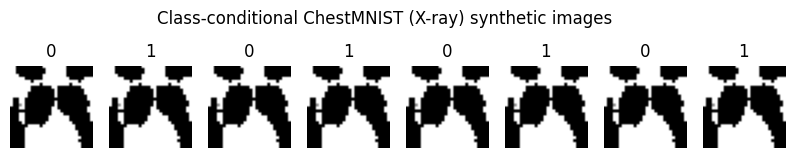

In [21]:
# 7. Visualize
G.eval(); decoder.eval()
n_samples = 8
noise = torch.randn(n_samples, NOISE_DIM, device=DEVICE)
sample_labels = torch.arange(n_samples, device=DEVICE) % N_CLASSES
z = G(noise, sample_labels)
with torch.no_grad():
    fake_imgs = decoder(z, sample_labels).cpu()
plt.figure(figsize=(10,2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i+1)
    plt.imshow(fake_imgs[i,0], cmap='gray')
    plt.title(f"{sample_labels[i].item()}")
    plt.axis('off')
plt.suptitle("Class-conditional ChestMNIST (X-ray) synthetic images")
plt.show()

In [22]:
G.eval(); decoder.eval()
n_samples = 128  # or more for FID!
noise = torch.randn(n_samples, NOISE_DIM, device=DEVICE)
sample_labels = torch.randint(0, N_CLASSES, (n_samples,), device=DEVICE)
z = G(noise, sample_labels)
with torch.no_grad():
    fake_imgs = decoder(z, sample_labels).cpu()
save_generated_images(fake_imgs, sample_labels, out_dir='generated_xray')


Saved 128 images to generated_xray/


In [14]:
! pip install torchmetrics -q
!pip install torchmetrics[image] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 48.5 MB/s eta 0:00:00


In [23]:
from torchmetrics.image.fid import FrechetInceptionDistance

# Prepare real and fake images (resize and convert to 3 channels if needed)
def expand_to_rgb(x):
    # x: [N,1,H,W] -> [N,3,H,W]
    return x.expand(-1, 3, -1, -1)

def get_real_batch(test_loader, num_samples):
    imgs, _ = next(iter(test_loader))
    return imgs[:num_samples]

# Get real images
real_imgs = get_real_batch(test_loader, n_samples)
real_imgs = expand_to_rgb(real_imgs)

# Get fake images (already generated above)
fake_imgs_rgb = expand_to_rgb(fake_imgs)

# FID computation
fid = FrechetInceptionDistance(normalize=True).to(DEVICE)
fid.update(real_imgs.to(DEVICE), real=True)
fid.update(fake_imgs_rgb.to(DEVICE), real=False)
fid_score = fid.compute().item()
print(f"FID score (lower is better): {fid_score:.2f}")


FID score (lower is better): 369.91
